<a href="https://colab.research.google.com/github/ryueuitae-blip/AIEYES-STUDY/blob/suyeon_branch/%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_%EB%B0%8F_%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style('whitegrid') # 그래프의 배경: 하얀 격자무늬로 설정

# 타이타닉 데이터 불러오기
titanic = sns.load_dataset('titanic')

In [ ]:
# 데이터 미리보기: 첫 5행 출력 -> 컬럼 구성과 데이터 형태 파
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# 요약 통계량 확인
titanic.describe()
# 숫자형 컬럼들의 데이터 개수, 평균, 표준편차, 최솟값, 최댓값 등

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# 결측치 제거 후 통계량 확인
titanic.dropna().describe()
# 데이터 중 누락된 값(NaN)이 있는 행을 모두 삭

,survived,pclass,age,sibsp,parch,fare
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,0.675824,1.192308,35.623187,0.467033,0.478022,78.919735
std,0.469357,0.516411,15.671615,0.645007,0.755869,76.490774
min,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,1.000000,1.000000,47.750000,1.000000,1.000000,90.000000
max,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


In [ ]:
# titanic.var()
# 오류 원인: 최신 버전의 Pandas에서는 이런 통계 함수를 쓸 때 문자열이 섞여 있으면 기본적으로 에러를 띄우도록 변경되었음

# 분산 계산
titanic.var(numeric_only=True)
# 숫자형 컬럼만 계산

,0
survived,0.236772
pclass,0.699015
age,211.019125
sibsp,1.216043
parch,0.649728
fare,2469.436846
adult_male,0.239723
alone,0.239723


In [ ]:
# 오류: titanic.mad()
# 오류 원인: mad(평균 절대 편차를 구하는 함수)가 잘 쓰이지 않다 보니 Pandas 버전 2.0.0부터 완전히 삭제됨

# mad 대안 계산

# 1. 숫자형 데이터만 있는 열(Column)을 따로 저장
numeric_titanic = titanic.select_dtypes(include=np.number)

# 2. (데이터 - 평균)의 절댓값을 구하고, 다시 그것의 평균을 구함
mad_values = (numeric_titanic - numeric_titanic.mean()).abs().mean()

print(mad_values)

survived     0.473013
pclass       0.761968
age         11.322944
sibsp        0.713780
parch        0.580742
fare        28.163692
dtype: float64


In [ ]:
# 클래스별 데이터 개수 세기
titanic.groupby('class').count()

/tmp/ipykernel_4675/541535806.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class').count()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
class,,,,,,,,,,,,,,
First,216,216,216,186,216,216,216,214,216,216,175,214,216,216
Second,184,184,184,173,184,184,184,184,184,184,16,184,184,184
Third,491,491,491,355,491,491,491,491,491,491,12,491,491,491


<Axes: xlabel='count', ylabel='class'>

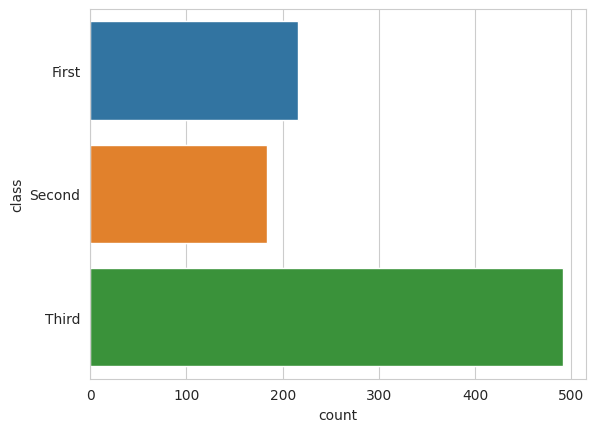

In [ ]:
# 클래스별 데이터 개수 시각화 (가로 막대형 그래프)
sns.countplot(y='class', data=titanic);

# 색깔 막대 별로 다르게 하고 싶을 경우
sns.countplot(y='class', data=titanic, hue='class')
# y축 기준인 'class'를 hue에도 똑같이 지정

<Axes: xlabel='count', ylabel='alive'>

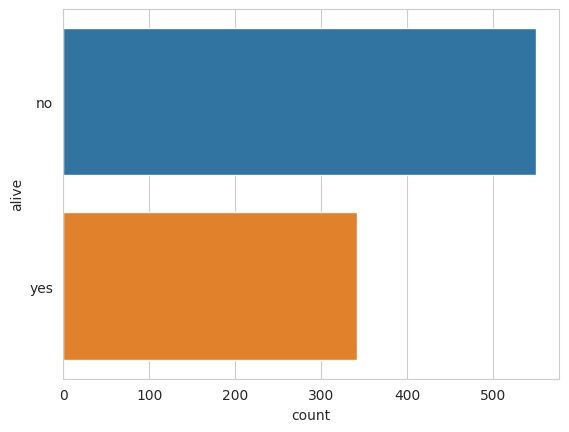

In [ ]:
# 생존 여부별 탑승객 수 시각화
sns.countplot(y='alive', data=titanic, hue = 'alive')

<Axes: xlabel='count', ylabel='alone'>

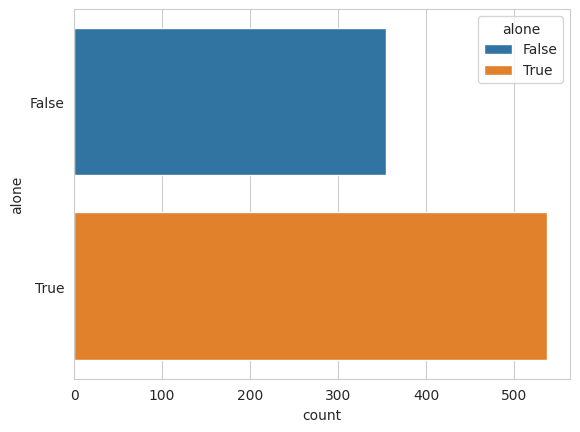

In [ ]:
# 동승자 여부별 탑승객 수 시각화
sns.countplot(y='alone', data=titanic, hue = 'alone')

In [ ]:
# titanic.groupby('class').std()
# 오류 원인: 최신 버전의 Pandas에서는 이런 통계 함수를 쓸 때 문자열이 섞여 있으면 기본적으로 에러를 띄우도록 변경되었음

# 객실 등급별 표준편차(std) 계산
titanic.groupby('class').std(numeric_only=True)
# 숫자로 된 컬럼만 계산

/tmp/ipykernel_4675/3935499372.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class').std(numeric_only=True)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
class,,,,,,,,
First,0.484026,0.0,14.802856,0.611898,0.693997,78.380373,0.498555,0.501140
Second,0.500623,0.0,14.001077,0.601633,0.690963,13.417399,0.499911,0.497081
Third,0.428949,0.0,12.495398,1.374883,0.888861,11.778142,0.477552,0.474233


In [ ]:
# 객실 등급별 요금의 중앙값 계산
titanic.groupby('class')['fare'].median()
# 평균: 극단적인 값에 영향을 많이 받음
# -> 요금처럼 편차가 큰 데이터는 중앙값을 보는 것이 더 정확함

/tmp/ipykernel_4675/3434014833.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class')['fare'].median()


,fare
class,
First,60.2875
Second,14.2500
Third,8.0500


In [ ]:
# 특정 조건 필터링: 전체 승객 중 생존자만 추출
titanic.query("alive == 'yes'")

# titanic.query('alive == 'yes'') 는 오류
# 오류 원인: 파이썬은 처음 열린 따옴표와 똑같이 생긴 따옴표를 만나는 순간 문자열이 끝났다고 판단

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [ ]:
# 생존자를 필터링한 후 객실 등급별로 인원수 세기
titanic.query("alive == 'yes'").groupby('class').count()

/tmp/ipykernel_4675/309516766.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query("alive == 'yes'").groupby('class').count()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
class,,,,,,,,,,,,,,
First,136,136,136,122,136,136,136,134,136,136,117,134,136,136
Second,87,87,87,83,87,87,87,87,87,87,13,87,87,87
Third,119,119,119,85,119,119,119,119,119,119,6,119,119,119


In [ ]:
# 객실 등급별 '나이'의 요약 통계량
titanic.groupby('class')['age'].describe()

/tmp/ipykernel_4675/1607951913.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class')['age'].describe()


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
First,186.0,38.233441,14.802856,0.92,27.0,37.0,49.0,80.0
Second,173.0,29.877630,14.001077,0.67,23.0,29.0,36.0,70.0
Third,355.0,25.140620,12.495398,0.42,18.0,24.0,32.0,74.0


In [ ]:
# 생존자들의 객실 등급별 요약 통계량
titanic.query("alive == 'yes'").groupby('class').describe()

/tmp/ipykernel_4675/88605987.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query("alive == 'yes'").groupby('class').describe()


survived                                    pclass       ... parch  \
          count mean  std  min  25%  50%  75%  max  count mean  ...   75%   
class                                                           ...         
First     136.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  136.0  1.0  ...   1.0   
Second     87.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   87.0  2.0  ...   1.0   
Third     119.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  119.0  3.0  ...   1.0   

              fare                                                    \
        max  count       mean        std      min       25%      50%   
class                                                                  
First   2.0  136.0  95.608029  85.286820  25.9292  50.98545  77.9583   
Second  3.0   87.0  22.055700  10.853502  10.5000  13.00000  21.0000   
Third   5.0  119.0  13.694887  10.692993   0.0000   7.77500   8.5167   

                              
               75%       max  
class                         
First   111.481225  512.3292  
Second   26.250000   65.0000  
Third    15.875000   56.4958  

[3 rows x 48 columns]

In [ ]:
# 성별별로 나이의 특정 통계량 (min, np.median, max)
titanic.groupby('sex')['age'].aggregate([min, np.median, max])

/tmp/ipykernel_4675/2186752428.py:1: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  titanic.groupby('sex')['age'].aggregate([min, np.median, max])
/tmp/ipykernel_4675/2186752428.py:1: FutureWarning: The provided callable <function median at 0x7ad94814d940> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  titanic.groupby('sex')['age'].aggregate([min, np.median, max])
/tmp/ipykernel_4675/2186752428.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  titanic.groupby('sex')['age'].aggregate([min, 

,min,median,max
sex,,,
female,0.75,27.0,63.0
male,0.42,29.0,80.0


In [ ]:
# titanic.query('age > 30').groupby('class').median()
# 오류 원인: 성별('male'), 탑승 항구('Southampton') 같은 글자 데이터의 경우 중앙값을 계산할 수 X

# 30세 초과 승객들의 객실 등급별 데이터의 중앙값
titanic.query('age > 30').groupby('class').median(numeric_only=True)
# numeric_only=True: 숫자로 된 칼럼만 계산

/tmp/ipykernel_4675/674695759.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query('age > 30').groupby('class').median(numeric_only=True)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
class,,,,,,,,
First,1.0,1.0,45.0,0.0,0.0,56.9292,1.0,0.0
Second,0.0,2.0,39.0,0.0,0.0,14.0000,1.0,1.0
Third,0.0,3.0,38.0,0.0,0.0,8.0500,1.0,1.0


In [ ]:
# 요금 20달러 미만 승객들의 객실 등급별 숫자 데이터의 중앙값
titanic.query('fare < 20').groupby('class').median(numeric_only = True)

/tmp/ipykernel_4675/1388460838.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query('fare < 20').groupby('class').median(numeric_only = True)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
class,,,,,,,,
First,0.0,1.0,38.5,0.0,0.0,0.0000,1.0,1.0
Second,0.0,2.0,30.0,0.0,0.0,13.0000,1.0,1.0
Third,0.0,3.0,25.0,0.0,0.0,7.8958,1.0,1.0


In [ ]:
# 객실 등급, 성별 기준으로 나이 평균 구하기
titanic.groupby(['class', 'sex'])['age'].mean().unstack()

# unstack(): 길게 세로로 나열된 결과를 가로, 세로의 2차원 표로 정리

/tmp/ipykernel_4675/2728676293.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(['class', 'sex'])['age'].mean().unstack()


sex,female,male
class,,
First,34.611765,41.281386
Second,28.722973,30.740707
Third,21.750000,26.507589


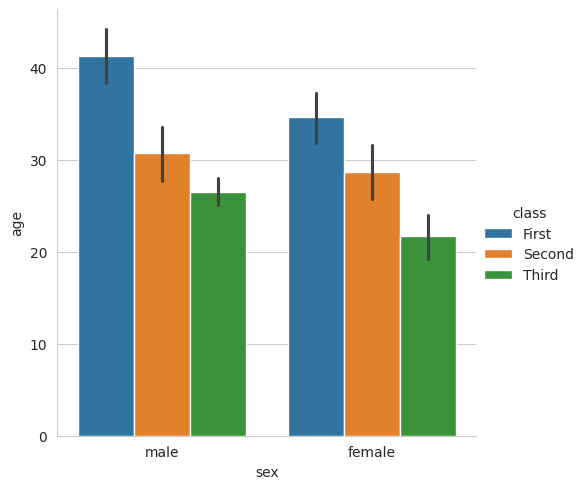

In [ ]:
# 성별별, 객실 등급별 평균 나이 시각화
sns.catplot(x='sex', y='age',
            hue='class', kind='bar',
            data=titanic)

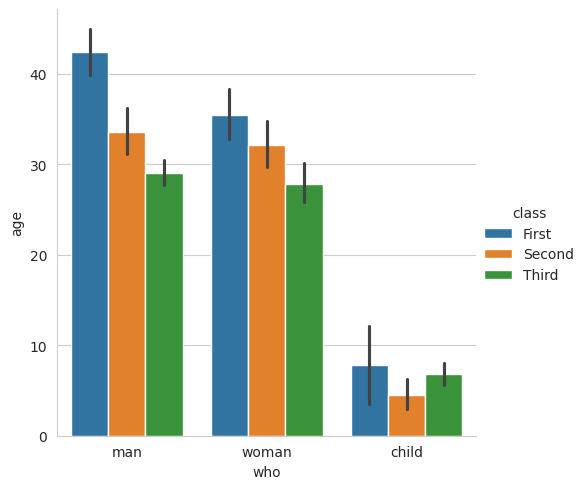

In [ ]:
# 탑승객 유형별, 객실 등급별 평균 나이 시각화
sns.catplot(x='who', y='age',
            hue='class', kind='bar',
            data=titanic)

In [ ]:
# 객실 등급, 성별 기준으로 요금 평균 구하기
titanic.groupby(['class', 'sex'])['fare'].mean().unstack()

/tmp/ipykernel_4675/1321698963.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(['class', 'sex'])['fare'].mean().unstack()


sex,female,male
class,,
First,106.125798,67.226127
Second,21.970121,19.741782
Third,16.118810,12.661633


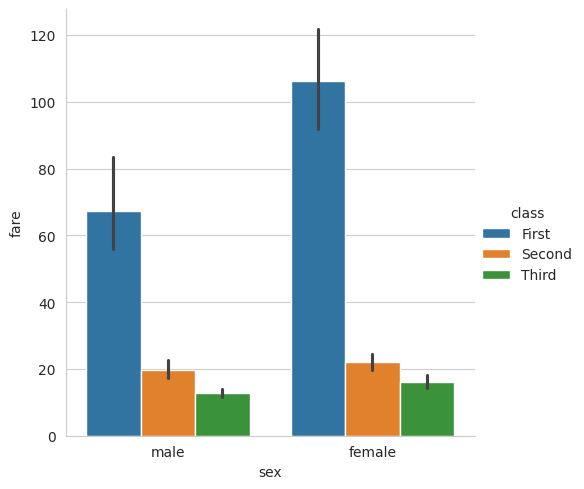

In [ ]:
# 성별별, 객실 등급별 평균 요금 시각화
sns.catplot(x='sex', y='fare',
            hue='class', kind='bar',
            data=titanic);

# 궁금증1: 마지막 부분에 세미콜론(;) 붙이는 이유 --- 그냥 실행 시 이 함수가 만들어낸 객체의 정보(텍스트)가 그래프 위에 반환됨
# 세미콜론 -> 객체의 정보는 숨겨지고, 그래프만 나타남

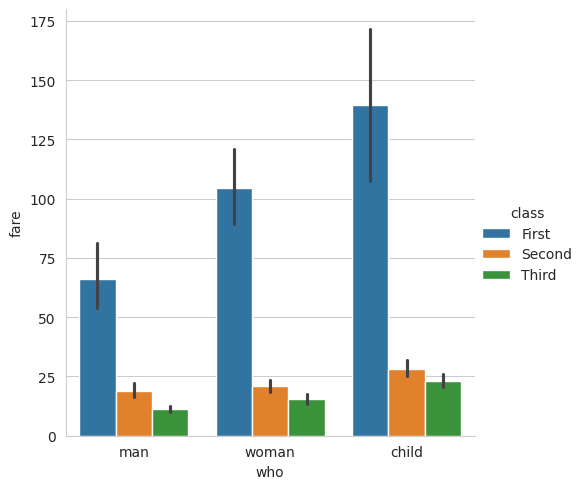

In [ ]:
# 탑승객 유형별, 등급별 평균 요금 시각화
sns.catplot(x='who', y='fare',
            hue='class', kind='bar',
            data=titanic);

In [ ]:
# 객실 등급, 성별 기준으로 생존 평균 구하기
titanic.groupby(['class', 'sex'])['survived'].mean().unstack()

# 생존:1, 사망:0인 데이터에서 평균을 구하면 생존율이 계산됨

/tmp/ipykernel_4675/3045898648.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(['class', 'sex'])['survived'].mean().unstack()


sex,female,male
class,,
First,0.968085,0.368852
Second,0.921053,0.157407
Third,0.500000,0.135447


In [ ]:
# 객실 등급별 & 탑승객 유형별 생존율 표
titanic.pivot_table('survived', index='class', columns='who')

/tmp/ipykernel_4675/1157413278.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='class', columns='who')


who,child,man,woman
class,,,
First,0.833333,0.352941,0.978022
Second,1.000000,0.080808,0.909091
Third,0.431034,0.119122,0.491228


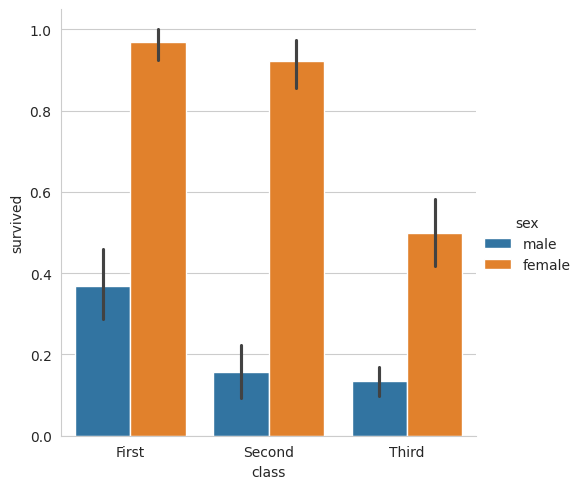

In [ ]:
# 객실 등급별, 성별별 생존율 시각화
sns.catplot(x='class', y='survived',
            hue='sex', kind='bar',
            data=titanic)

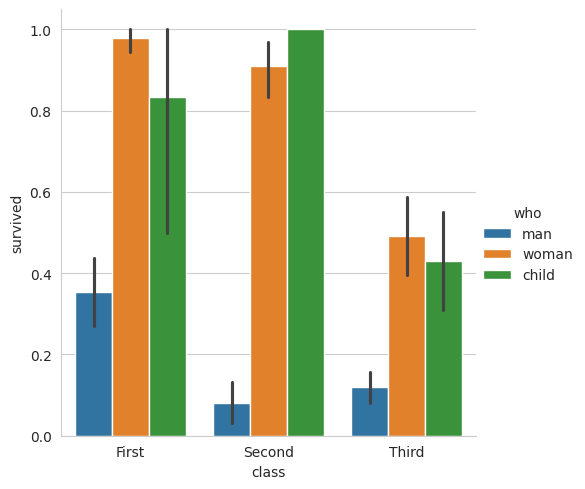

In [ ]:
# 객실 등급별, 탑승객 유형별 생존율 시각화
sns.catplot(x='class', y='survived',
            hue='who', kind='bar',
            data=titanic)

In [ ]:
# 나이 구간 설정하기 (pd.cut)
age = pd.cut(titanic['age'], [0, 18, 40, 80]) # [0~18], [18~40], [40~80] 구간
titanic.pivot_table('survived', ['sex', age], 'class')
# 행: 성별, 연령대 / 열: 객실 등급 -> 생존율 표

# 궁금증2: ['sex', age]에서 왜 sex는 따옴표 있고 age는 없는지?
# 'sex': titanic 데이터 안에서 이름이 'sex'라고 적힌 컬럼 찾기
# age: 윗줄에서 만들어둔 age라는 변수를 가져다 쓰기

/tmp/ipykernel_4675/3512716547.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', ['sex', age], 'class')


class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 40]  0.979167  0.914894  0.480000
       (40, 80]  0.961538  0.846154  0.111111
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 40]  0.478261  0.063492  0.146199
       (40, 80]  0.280000  0.095238  0.064516

In [ ]:
age = pd.cut(titanic['age'], [0, 18, 40, 80])
titanic.pivot_table('survived', ['who', age], 'class')
# 행: 탑승객 유형, 연령대 / 열: 객실 등급 -> 생존율 표

/tmp/ipykernel_4675/2658073663.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', ['who', age], 'class')


class              First    Second     Third
who   age                                   
child (0, 18]   0.833333  1.000000  0.431034
man   (0, 18]   0.500000  0.000000  0.086957
      (18, 40]  0.478261  0.063492  0.146199
      (40, 80]  0.280000  0.095238  0.064516
woman (0, 18]   1.000000  1.000000  0.461538
      (18, 40]  0.979167  0.914894  0.480000
      (40, 80]  0.961538  0.846154  0.111111

In [ ]:
# 요금을 동일한 길이로 3등분
fare = pd.cut(titanic['fare'], 3)

titanic.pivot_table('survived', ['who', fare], 'class')
# 행: 탑승객 유형, 요금 / 열: 객실 등급 -> 생존율 표

/tmp/ipykernel_4675/3187653097.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', ['who', fare], 'class')


class                       First    Second     Third
who   fare                                           
child (-0.512, 170.776]   0.80000  1.000000  0.431034
      (170.776, 341.553]  1.00000       NaN       NaN
man   (-0.512, 170.776]   0.36036  0.080808  0.119122
      (170.776, 341.553]  0.00000       NaN       NaN
      (341.553, 512.329]  1.00000       NaN       NaN
woman (-0.512, 170.776]   0.97500  0.909091  0.491228
      (170.776, 341.553]  1.00000       NaN       NaN
      (341.553, 512.329]  1.00000       NaN       NaN

In [ ]:
fare = pd.qcut(titanic['fare'], 3)

titanic.pivot_table('survived', ['who', age], [fare, 'class'])
# 행: 탑승객 유형, 나이 / 열: 요금, 객실 등급 -> 생존율 표

/tmp/ipykernel_4675/2108634071.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', ['who', age], [fare, 'class'])


fare           (-0.001, 8.662]           (8.662, 26.0]                      \
class                    First     Third         First    Second     Third   
who   age                                                                    
child (0, 18]              NaN  0.666667           NaN  1.000000  0.703704   
man   (0, 18]              NaN  0.125000           NaN  0.000000  0.000000   
      (18, 40]             0.0  0.138462           NaN  0.078431  0.114286   
      (40, 80]             NaN  0.074074           0.0  0.111111  0.000000   
woman (0, 18]              NaN  0.666667           NaN  1.000000  0.333333   
      (18, 40]             NaN  0.550000           NaN  0.894737  0.461538   
      (40, 80]             NaN  0.000000           1.0  0.818182  0.250000   

fare           (26.0, 512.329]               
class                    First Second Third  
who   age                                    
child (0, 18]         0.833333    1.0  0.08  
man   (0, 18]         0.500000    0.0  0.00  
      (18, 40]        0.523810    0.0  0.50  
      (40, 80]        0.291667    0.0   NaN  
woman (0, 18]         1.000000    NaN  0.00  
      (18, 40]        0.979167    1.0  0.25  
      (40, 80]        0.958333    1.0  0.00

In [ ]:
# 피벗 테이블에 총계 평균 추가하기 (margins=True)
titanic.pivot_table('survived', index='who', columns='class', margins=True)

/tmp/ipykernel_4675/1757417891.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='who', columns='class', margins=True)


class,First,Second,Third,All
who,,,,
child,0.833333,1.000000,0.431034,0.590361
man,0.352941,0.080808,0.119122,0.163873
woman,0.978022,0.909091,0.491228,0.756458
All,0.629630,0.472826,0.242363,0.383838


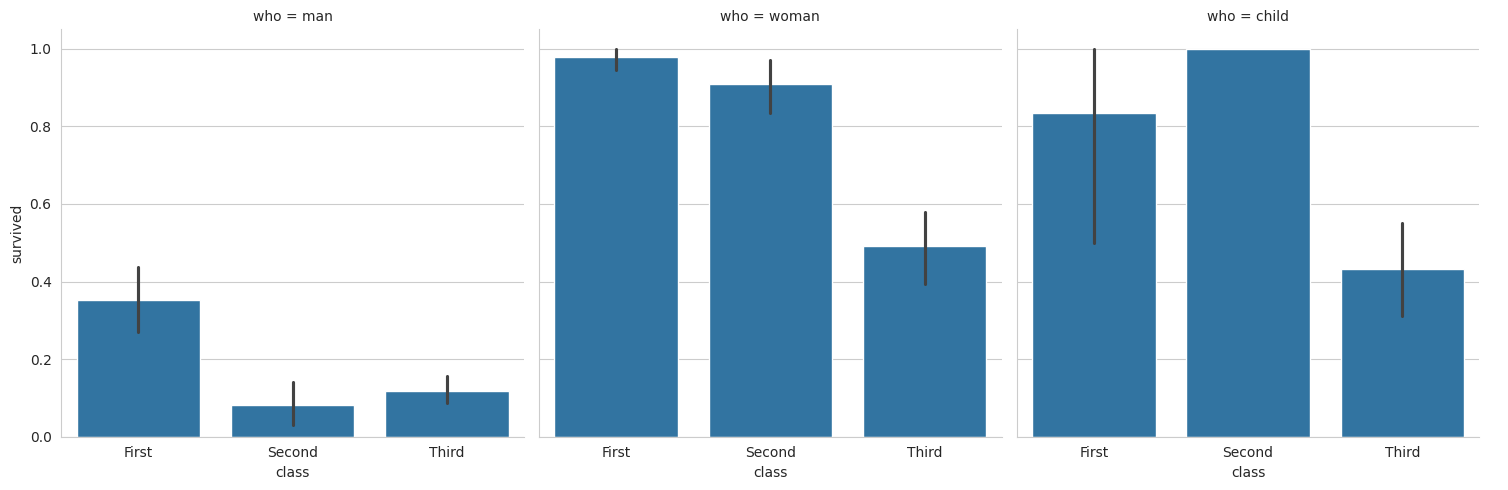

In [ ]:
# 그래프를 탑승객 유형에 따라 쪼개어 그리기 (col)
sns.catplot(x='class', y='survived',
            col='who', kind='bar',
            data=titanic)

In [ ]:
# 갑판 구역별 & 객실 등급별 총계 포함 생존율
titanic.pivot_table('survived', index='deck', columns='class', margins=True)

/tmp/ipykernel_4675/2562194539.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='deck', columns='class', margins=True)


class,First,Second,Third,All
deck,,,,
A,0.466667,NaN,NaN,0.466667
B,0.744681,NaN,NaN,0.744681
C,0.593220,NaN,NaN,0.593220
D,0.758621,0.7500,NaN,0.757576
E,0.720000,0.7500,1.0,0.750000
F,NaN,0.8750,0.2,0.615385
G,NaN,NaN,0.5,0.500000
All,0.668571,0.8125,0.5,0.669951


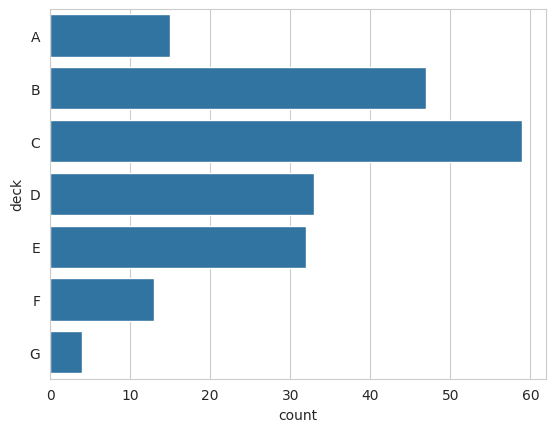

In [ ]:
# 갑판 구역별 탑승객 수 시각화
sns.countplot(y='deck', data=titanic);

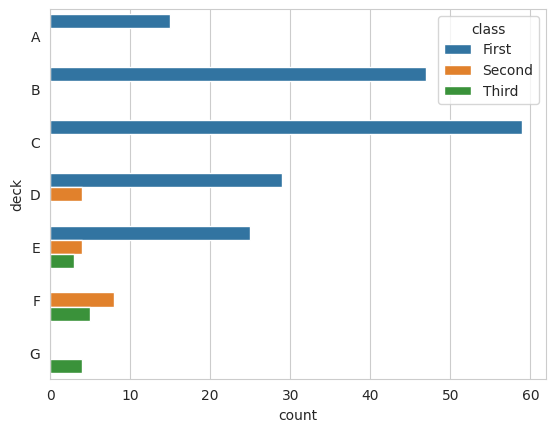

In [ ]:
# 갑판 구역별 탑승객 수를 객실 등급으로 쪼개어 보기
sns.countplot(y='deck', hue='class', data=titanic);

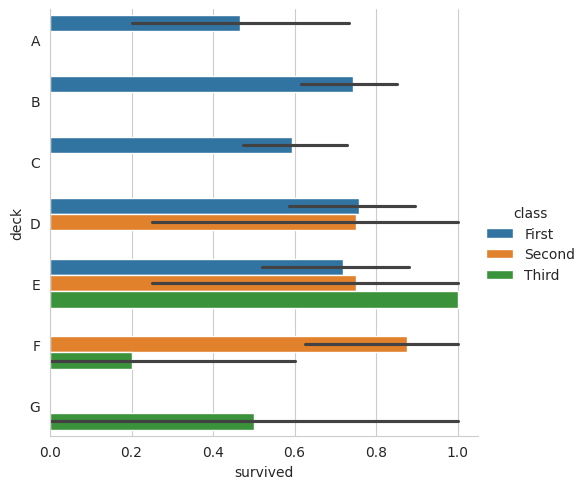

In [ ]:
# 갑판 구역별 & 객실 등급별 생존율 시각화
sns.catplot(x='survived', y='deck',
            hue='class', kind='bar',
            data=titanic);

# 궁금증3: 따로 가로그래프, 세로그래프 설정을 하지 않았는데 왜 어떨 때는 세로 그래프고 어떨 때는 가로 그래프인가?
# -> catplot은 글자 데이터, 숫자 데이터를 스스로 판단하여 눈치껏 글자 데이터를 고정 축으로 하여 그래프를 그려줌

In [ ]:
# 탑승 항구별 & 객실 등급별 생존율 피벗 테이블 (총계 포함)
titanic.pivot_table('survived', index='embark_town', columns='class', margins=True)

/tmp/ipykernel_4675/3925685494.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='embark_town', columns='class', margins=True)


class,First,Second,Third,All
embark_town,,,,
Cherbourg,0.694118,0.529412,0.378788,0.553571
Queenstown,0.500000,0.666667,0.375000,0.389610
Southampton,0.582677,0.463415,0.189802,0.336957
All,0.626168,0.472826,0.242363,0.382452


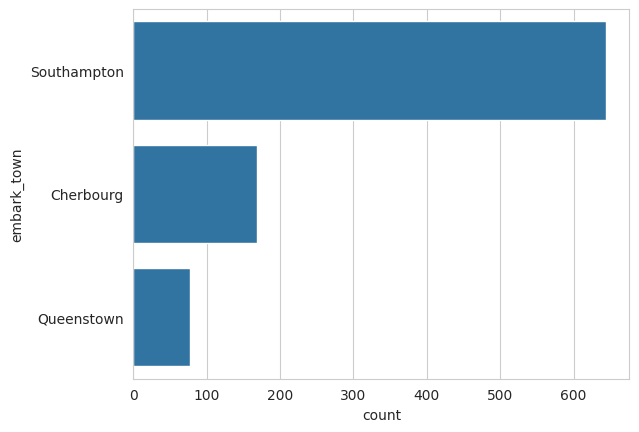

In [ ]:
# 탑승 항구별 총 인원수 시각화
sns.countplot(y='embark_town', data=titanic);

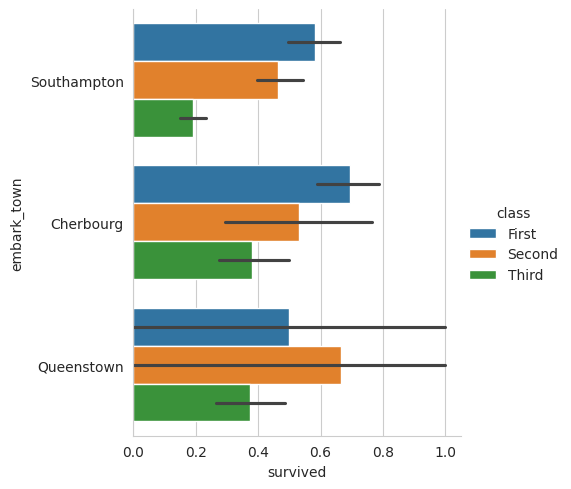

In [ ]:
# 탑승 항구별 & 객실 등급별 생존율 시각화
sns.catplot(x='survived', y='embark_town',
            hue='class', kind='bar',
            data=titanic);

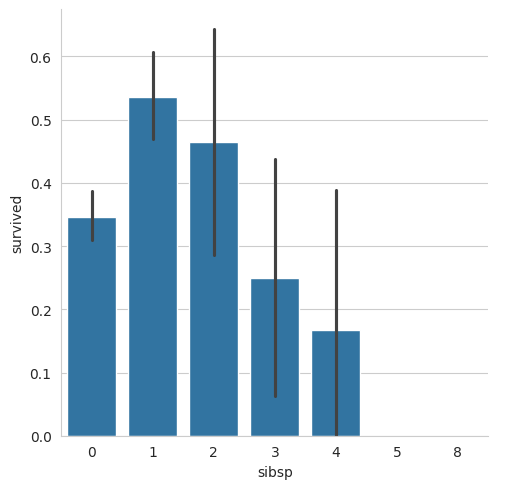

In [ ]:
# 형제/자매/배우자(sibsp)별 생존율
sns.catplot(x='sibsp', y='survived',
            kind='bar', data=titanic)

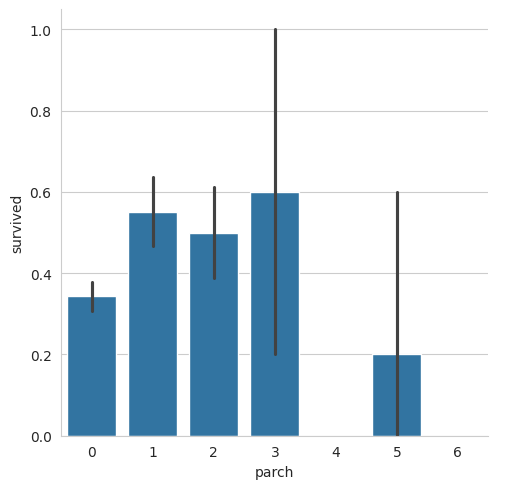

In [ ]:
# 부모/자녀(parch)에 따른 생존율
sns.catplot(x='parch', y='survived',
            kind='bar', data=titanic)

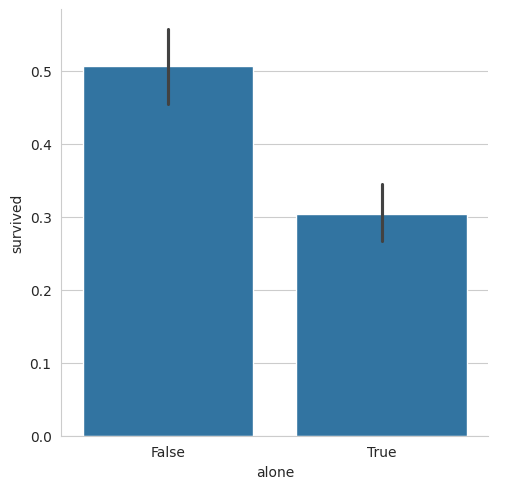

In [ ]:
# 혼자 탑승 여부에 따른 생존율
sns.catplot(x='alone', y='survived',
            kind='bar', data=titanic)